# Stock Market Movement Prediction from News Headlines
### Can daily news headlines predict whether the DJIA goes up or down?

I built this NLP pipeline to predict daily DJIA (Dow Jones Industrial Average) stock market movement using Reddit news headlines from 2008 to 2016.

**The core idea:** Financial markets react to news. If today's top headlines are negative — war, recession, scandal — the market tends to drop. I wanted to test how well NLP features extracted from headlines could predict that movement.

**My pipeline:**
1. Data loading and EDA
2. Text preprocessing — tokenization, stopword removal, lemmatization
3. Feature engineering — TF-IDF, VADER sentiment, lagged features, Named Entity Recognition
4. Model training — Random Forest, Logistic Regression, Naive Bayes
5. Model comparison and error analysis
6. Honest conclusions about why financial NLP is hard

**Target variable:**
- Label = 1: DJIA closed higher than it opened (market went UP)
- Label = 0: DJIA closed lower than it opened (market went DOWN)

**Train/Test split:** 2008-08-08 to 2014-12-31 (train) | 2015-01-02 to 2016-07-01 (test)

---
## 1. Imports

In [5]:
#pip install wordcloud

import warnings
warnings.filterwarnings('ignore')

# core
import re
import random
import zipfile
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import pos_tag, ne_chunk, FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

# modeling
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import statsmodels.api as sm

# download required NLTK data
for pkg in ['punkt_tab', 'stopwords', 'wordnet', 'omw-1.4',
            'vader_lexicon', 'averaged_perceptron_tagger', 'maxent_ne_chunker', 'words']:
    nltk.download(pkg, quiet=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
random.seed(42)
np.random.seed(42)

print('All libraries loaded.')

All libraries loaded.


---
## 2. Load Data

I'm using the Kaggle **Stocknews** dataset which contains:
- `Combined_News_DJIA.csv` — Top 25 Reddit news headlines per day + DJIA label (up/down)
- `upload_DJIA_table.csv` — Daily DJIA open/close prices
- `RedditNews.csv` — Raw Reddit headlines

The dataset covers 2008–2016, with the 2015–2016 period held out as test data.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("aaron7sun/stocknews")

combined_df  = pd.read_csv(f'{path}/Combined_News_DJIA.csv')
stock_prices = pd.read_csv(f'{path}/upload_DJIA_table.csv')

print(f'combined_df:  {combined_df.shape[0]:,} rows, {combined_df.shape[1]} columns')
print(f'stock_prices: {stock_prices.shape[0]:,} rows, {stock_prices.shape[1]} columns')
print()

print('=== combined_df preview ===')
print(combined_df.head(3))

combined_df:  1,989 rows, 27 columns
stock_prices: 1,989 rows, 7 columns

=== combined_df preview ===
         Date  Label                                               Top1  \
0  2008-08-08      0  b"Georgia 'downs two Russian warplanes' as cou...   
1  2008-08-11      1  b'Why wont America and Nato help us? If they w...   
2  2008-08-12      0  b'Remember that adorable 9-year-old who sang a...   

                                          Top2  \
0      b'BREAKING: Musharraf to be impeached.'   
1  b'Bush puts foot down on Georgian conflict'   
2           b"Russia 'ends Georgia operation'"   

                                                Top3  \
0  b'Russia Today: Columns of troops roll into So...   
1  b"Jewish Georgian minister: Thanks to Israeli ...   
2  b'"If we had no sexual harassment we would hav...   

                                                Top4  \
0  b'Russian tanks are moving towards the capital...   
1  b'Georgian army flees in disarray as Russians ...   
2  

---
## 3. EDA — Understanding the Data Before Modeling

Before touching the text, I want to understand:
- How balanced is the target label?
- What does the DJIA price trend look like over the dataset period?
- Are there any obvious patterns to exploit?

=== Target Label Distribution ===
Label
1    1065
0     924
Name: count, dtype: int64
Class balance: 46.5% down, 53.5% up


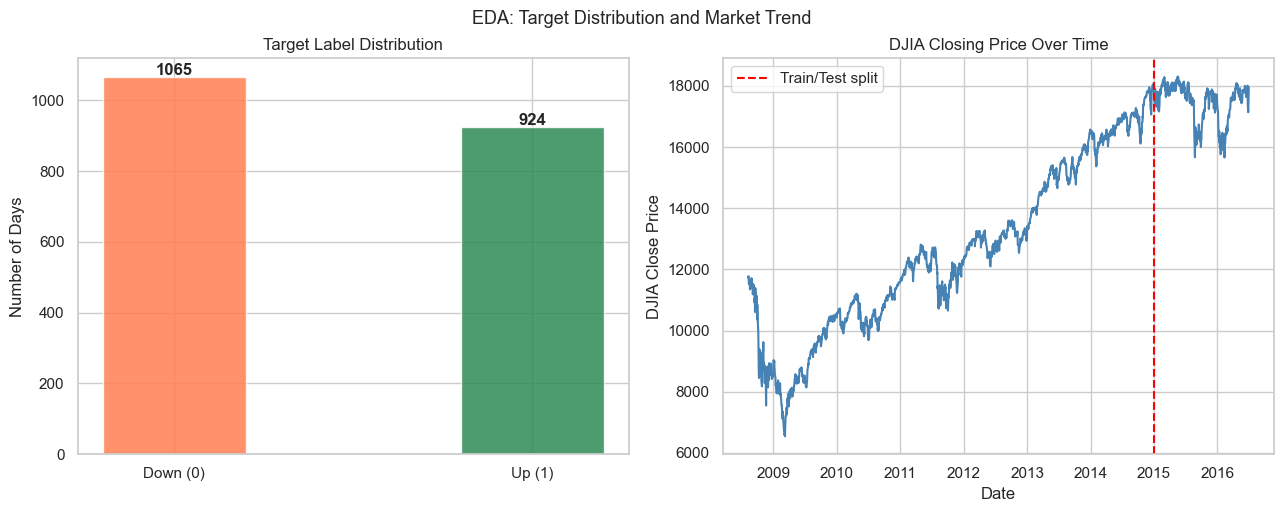

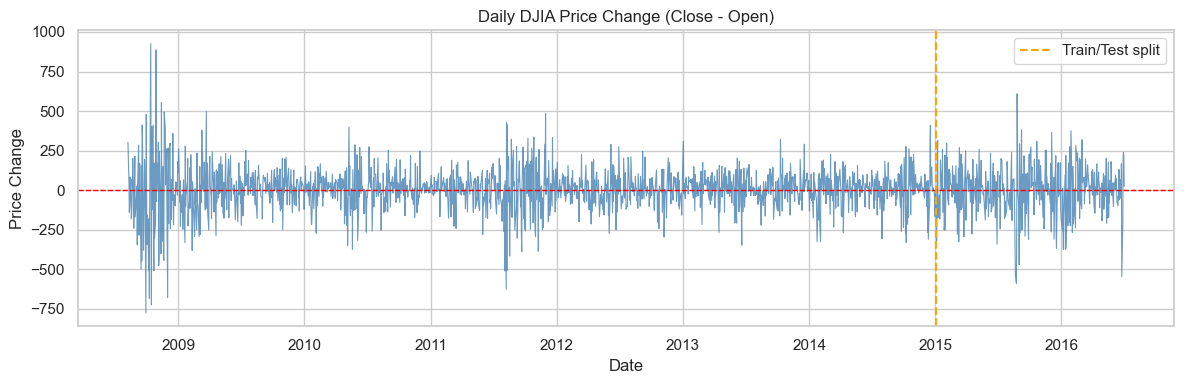

Observation: The dataset is slightly imbalanced (more up days than down).
I will use SMOTE + class_weight="balanced" to handle this later.


In [10]:
print('=== Target Label Distribution ===')
label_counts = combined_df['Label'].value_counts()
print(label_counts)
print(f'Class balance: {label_counts[0]/len(combined_df):.1%} down, {label_counts[1]/len(combined_df):.1%} up')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# label distribution
axes[0].bar(['Down (0)', 'Up (1)'], label_counts.values,
            color=['coral', 'seagreen'], alpha=0.85, width=0.4)
axes[0].set_title('Target Label Distribution')
axes[0].set_ylabel('Number of Days')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# DJIA price over time
stock_prices['Date'] = pd.to_datetime(stock_prices['Date'])
stock_prices_sorted = stock_prices.sort_values('Date')
axes[1].plot(stock_prices_sorted['Date'], stock_prices_sorted['Close'],
             color='steelblue', linewidth=1.5)
axes[1].axvline(pd.to_datetime('2015-01-02'), color='red', linestyle='--',
                linewidth=1.5, label='Train/Test split')
axes[1].set_title('DJIA Closing Price Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('DJIA Close Price')
axes[1].legend()

plt.tight_layout()
plt.suptitle('EDA: Target Distribution and Market Trend', fontsize=13, y=1.02)
plt.show()

# daily price change
stock_prices_sorted['Change_in_Price'] = stock_prices_sorted['Close'] - stock_prices_sorted['Open']
plt.figure(figsize=(12, 4))
plt.plot(stock_prices_sorted['Date'], stock_prices_sorted['Change_in_Price'],
         color='steelblue', linewidth=0.8, alpha=0.8)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.axvline(pd.to_datetime('2015-01-02'), color='orange', linestyle='--',
            linewidth=1.5, label='Train/Test split')
plt.title('Daily DJIA Price Change (Close - Open)')
plt.xlabel('Date')
plt.ylabel('Price Change')
plt.legend()
plt.tight_layout()
plt.show()

print('Observation: The dataset is slightly imbalanced (more up days than down).')
print('I will use SMOTE + class_weight="balanced" to handle this later.')

---
## 4. Text Preprocessing Pipeline

The raw headlines are messy — they contain Python byte string artifacts (`b'`, `b"`), escape characters, and noise. I clean them through a 4-step pipeline:

**Step 1 — Combine 25 headlines per day into one string**  
Each row has Top1 through Top25 columns. I join them with `||` as a separator.

**Step 2 — Clean byte string artifacts**  
Reddit headlines were scraped with Python 2, so they contain `b'headline'` formatting. I strip those.

**Step 3 — Tokenize**  
Split each string into individual words (tokens). `word_tokenize` handles punctuation better than `.split()`.

**Step 4 — Remove stopwords + Lemmatize**  
Stopwords ("the", "is", "at") add noise without signal. Lemmatization reduces words to their base form so "running", "ran", "runs" all become "run" — reducing feature space without losing meaning.

In [11]:
news_columns = [f'Top{i}' for i in range(1, 26)]

# step 1: combine 25 headlines per day
combined_df['Combined_Hlines'] = combined_df[news_columns].apply(
    lambda x: ' || '.join(x.astype(str)), axis=1
)

# step 2: clean byte string artifacts from Python 2 scraping
# removes b" b' and escape characters like \'
combined_df['Combined_Hlines'] = combined_df['Combined_Hlines'].apply(
    lambda x: re.sub(r"b[\"']", '', x)
)
combined_df['Combined_Hlines'] = combined_df['Combined_Hlines'].apply(
    lambda x: re.sub(r"[\'\"]", '', x)
)
combined_df['Combined_Hlines'] = combined_df['Combined_Hlines'].apply(
    lambda x: x.replace("\\'", "'")
)

# drop the original 25 individual columns — no longer needed
df = combined_df.drop(columns=news_columns).copy()

# step 3: tokenize
df['Tokens'] = df['Combined_Hlines'].apply(word_tokenize)

# step 4: remove stopwords
stop_words = set(stopwords.words('english'))
df['Tokens'] = df['Tokens'].apply(
    lambda tokens: [w for w in tokens if w.lower() not in stop_words]
)

# step 5: lemmatize
# converts: 'running' -> 'run', 'better' -> 'good', 'wolves' -> 'wolf'
lemmatizer = WordNetLemmatizer()
df['Lemmatized'] = df['Tokens'].apply(
    lambda tokens: [lemmatizer.lemmatize(t) for t in tokens]
)

# convert back to string for TF-IDF and VADER (both need string input, not tokens)
df['Cleaned_Text'] = df['Lemmatized'].apply(lambda tokens: ' '.join(tokens))

print(f'Processed {len(df):,} days of headlines')
print()
print('=== Sample — before vs after cleaning ===')
print(f'Raw:     {combined_df["Combined_Hlines"].iloc[0][:200]}')
print()
print(f'Cleaned: {df["Cleaned_Text"].iloc[0][:200]}')

Processed 1,989 days of headlines

=== Sample — before vs after cleaning ===
Raw:     Georgia downs two Russian warplanes as countries move to brink of war || BREAKING: Musharraf to be impeached. || Russia Today: Columns of troops roll into South Ossetia; footage from fighting (YouTube

Cleaned: Georgia down two Russian warplane country move brink war || BREAKING : Musharraf impeached . || Russia Today : Columns troop roll South Ossetia ; footage fighting ( YouTube ) || Russian tank moving to


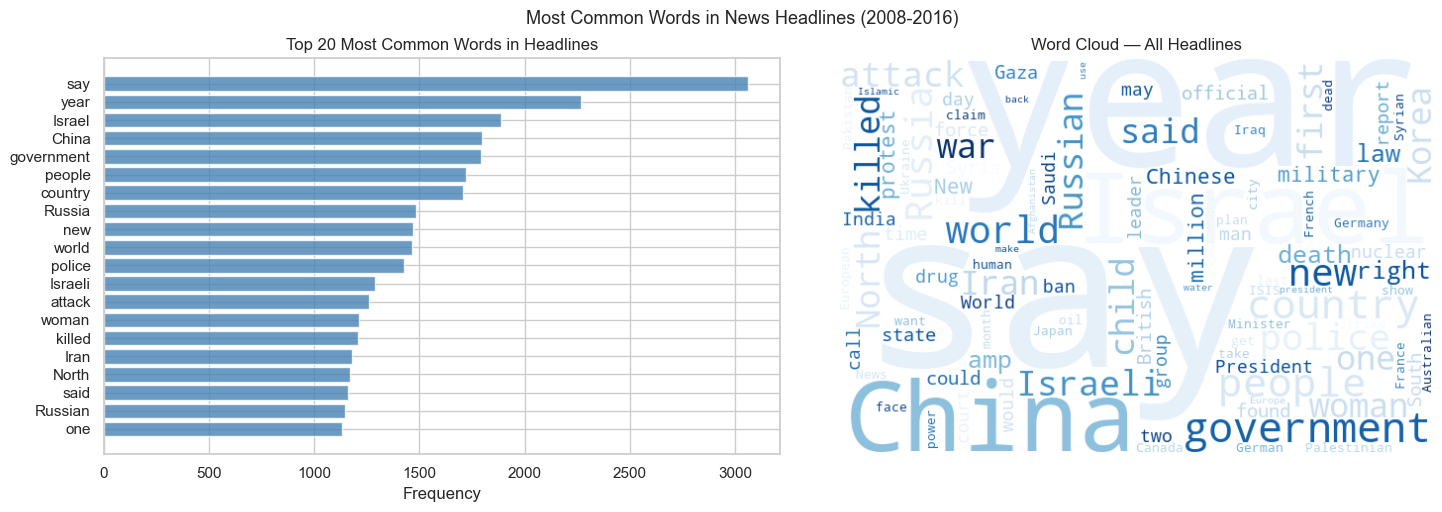

In [12]:
# visualize most common words across all headlines
# this gives me intuition about what the model will have to work with

all_words = [word for tokens in df['Lemmatized'] for word in tokens
             if word.isalpha() and len(word) > 2]
word_freq  = Counter(all_words)
top_words  = dict(word_freq.most_common(30))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# top 20 bar chart
top20 = dict(word_freq.most_common(20))
axes[0].barh(list(top20.keys())[::-1], list(top20.values())[::-1],
             color='steelblue', alpha=0.8)
axes[0].set_title('Top 20 Most Common Words in Headlines')
axes[0].set_xlabel('Frequency')

# wordcloud
wc = WordCloud(width=600, height=400, background_color='white',
               colormap='Blues', max_words=100, random_state=42)
wc.generate_from_frequencies(word_freq)
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud — All Headlines')

plt.tight_layout()
plt.suptitle('Most Common Words in News Headlines (2008-2016)', fontsize=13, y=1.02)
plt.show()

---
## 5. Feature Engineering

I extract three types of features from the cleaned headlines:

### 5a. TF-IDF (Term Frequency — Inverse Document Frequency)

TF-IDF gives each word a score representing how important it is to a specific day's headlines, relative to all other days:

$$\text{TF-IDF}(t, d) = \underbrace{\frac{\text{count of } t \text{ in } d}{\text{total words in } d}}_{\text{TF}} \times \underbrace{\log\frac{\text{total documents}}{\text{documents containing } t}}_{\text{IDF}}$$

- A word like "the" appears everywhere → low IDF → low TF-IDF score (filtered out naturally)
- A word like "recession" appears rarely → high IDF → high TF-IDF when present
- I use `ngram_range=(1,2)` to capture bigrams like "interest rate" or "stock market" as single features

### 5b. VADER Sentiment

VADER (Valence Aware Dictionary and sEntiment Reasoner) is specifically designed for social media and news text. It outputs:
- `compound`: overall sentiment (-1 = very negative, +1 = very positive)
- `pos`, `neg`, `neu`: proportion of positive/negative/neutral content

### 5c. Lagged Sentiment

Markets react to **yesterday's** news as much as today's. I add 1-day lagged versions of each sentiment score to capture this temporal dependency.

In [13]:
# --- 5a: TF-IDF ---
# max_features=1000: keep only top 1000 most informative terms
# ngram_range=(1,2): include both unigrams and bigrams
# min_df=5: ignore words appearing in fewer than 5 documents (reduces noise)

tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=5
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Cleaned_Text'])
tfidf_df     = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print(f'TF-IDF matrix shape: {tfidf_df.shape}')
print(f'Sample features: {list(tfidf_vectorizer.get_feature_names_out()[:10])}')

TF-IDF matrix shape: (1989, 1000)
Sample features: ['000', '10', '100', '11', '12', '13', '14', '15', '16', '17']


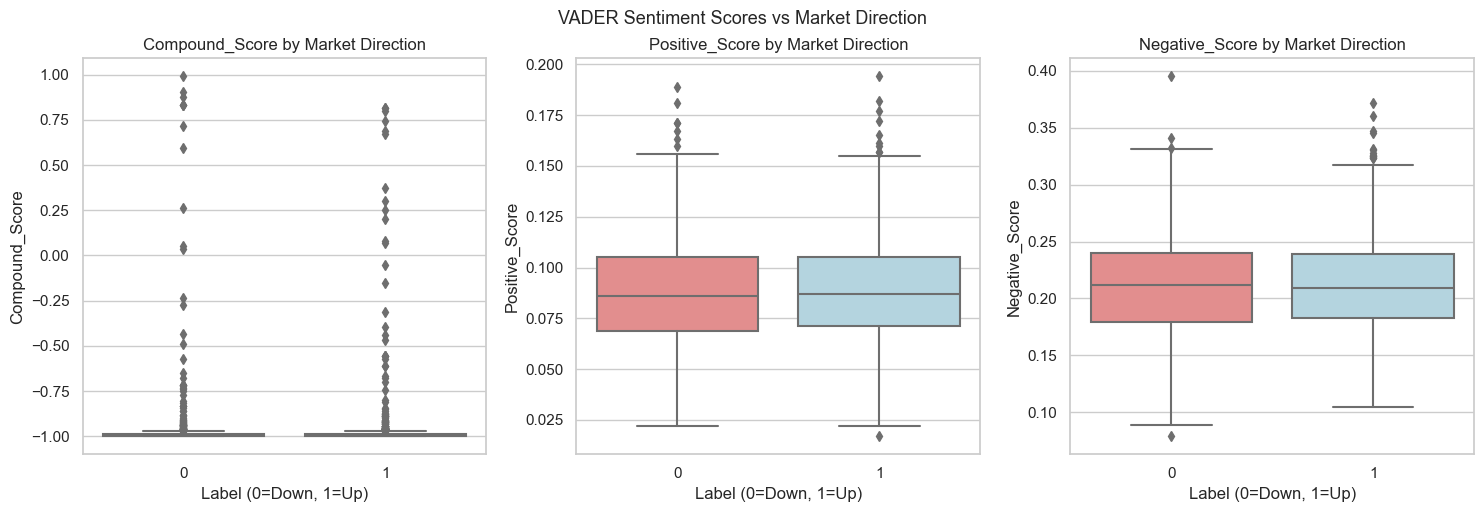

=== Correlation with Label ===
Positive_Score    0.012020
Negative_Score   -0.003225
Neutral_Score    -0.004189
Compound_Score   -0.004609
Name: Label, dtype: float64

Observation: sentiment scores show weak correlation with market movement.
This hints at the fundamental challenge — news alone is a noisy signal.


In [14]:
# --- 5b: VADER Sentiment ---
# VADER works on full sentences (not tokens), which is why I use Cleaned_Text
# It was built for news/social media text — perfect for this use case

sia = SentimentIntensityAnalyzer()

df['Compound_Score'] = df['Cleaned_Text'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['Positive_Score'] = df['Cleaned_Text'].apply(lambda x: sia.polarity_scores(x)['pos'])
df['Negative_Score'] = df['Cleaned_Text'].apply(lambda x: sia.polarity_scores(x)['neg'])
df['Neutral_Score']  = df['Cleaned_Text'].apply(lambda x: sia.polarity_scores(x)['neu'])

# visualize sentiment vs market direction
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, score, color in zip(
    axes,
    ['Compound_Score', 'Positive_Score', 'Negative_Score'],
    ['steelblue', 'seagreen', 'coral']
):
    sns.boxplot(x='Label', y=score, data=df, ax=ax,
                palette={0: 'lightcoral', 1: 'lightblue'})
    ax.set_title(f'{score} by Market Direction')
    ax.set_xlabel('Label (0=Down, 1=Up)')
    ax.set_ylabel(score)

plt.tight_layout()
plt.suptitle('VADER Sentiment Scores vs Market Direction', fontsize=13, y=1.02)
plt.show()

# correlation between sentiment and label
corr = df[['Positive_Score', 'Negative_Score', 'Neutral_Score', 'Compound_Score', 'Label']].corr()
print('=== Correlation with Label ===')
print(corr['Label'].drop('Label').sort_values(ascending=False))
print()
print('Observation: sentiment scores show weak correlation with market movement.')
print('This hints at the fundamental challenge — news alone is a noisy signal.')

In [15]:
# --- 5c: Lagged Features ---
# Markets react to yesterday's news — lagging captures this temporal pattern
# shift(1) means: today's lagged score = yesterday's actual score

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

for col in ['Compound_Score', 'Positive_Score', 'Negative_Score', 'Neutral_Score']:
    df[f'Lag_{col}'] = df[col].shift(1)

# merge with TF-IDF
final_df = pd.concat([df.reset_index(drop=True), tfidf_df], axis=1)

print(f'Final feature matrix shape: {final_df.shape}')
print(f'Columns: sentiment (4) + lagged sentiment (4) + TF-IDF (1000) = 1,008 features')

Final feature matrix shape: (1989, 1014)
Columns: sentiment (4) + lagged sentiment (4) + TF-IDF (1000) = 1,008 features


---
## 6. Named Entity Recognition (NER)

Beyond bag-of-words features, I extract named entities from headlines:
- **ORG**: organizations (Apple, Federal Reserve, Goldman Sachs)
- **GPE**: geopolitical entities (China, United States, Syria)
- **PER**: persons (Obama, Bernanke, Putin)

The intuition: certain organizations, countries, or people appearing in headlines may be systematically associated with market movements. For example, headlines mentioning "Federal Reserve" or "China" might correlate with specific market reactions.

I use these entity mentions as binary features for the Naive Bayes classifier.

In [16]:
def extract_entities(text):
    """Extract named entities (ORG, GPE, PER) from a text string."""
    tokens        = word_tokenize(text)
    tagged        = pos_tag(tokens)
    chunked       = ne_chunk(tagged)
    orgs, gpes, pers = set(), set(), set()
    for subtree in chunked:
        if isinstance(subtree, nltk.Tree):
            entity = ' '.join([c[0] for c in subtree])
            if subtree.label() == 'ORGANIZATION': orgs.add(entity)
            elif subtree.label() == 'GPE':        gpes.add(entity)
            elif subtree.label() == 'PERSON':     pers.add(entity)
    return list(orgs), list(gpes), list(pers)

print('Extracting named entities (this takes a few minutes)...')
final_df['ORG'], final_df['GPE'], final_df['PER'] = zip(
    *final_df['Cleaned_Text'].apply(extract_entities)
)
print('Done.')
print()
print('=== Sample NER output ===')
print(final_df[['Cleaned_Text', 'ORG', 'GPE', 'PER']].head(3))

Extracting named entities (this takes a few minutes)...
Done.

=== Sample NER output ===
                                        Cleaned_Text  \
0  Georgia down two Russian warplane country move...   
1  wont America Nato help u ? wont help u , help ...   
2  Remember adorable 9-year-old sang opening cere...   

                                                 ORG  \
0  [NATO, SOs, U.N., US News, FBI, VIDEO, Union, ...   
1                    [America Nato, US, New Zealand]   
2  [NATO, Ceasefire Georgia, BBC, un-Islamic, US,...   

                                                 GPE  \
0  [Israeli, Iraq, South, China, Iran, Georgia, E...   
1  [Iraq, Israeli, South, Israel US, Russians, Am...   
2  [Iraq, Israeli, Mexico, South, Russias, Americ...   

                                                 PER  
0  [Action Lawsuit Behalf American Public, Salim ...  
1  [Welcome World, Medal India, Ara, Arctic, Gori...  
2  [Microsoft Intel, Beats War Drum Iran Dumps Do...  


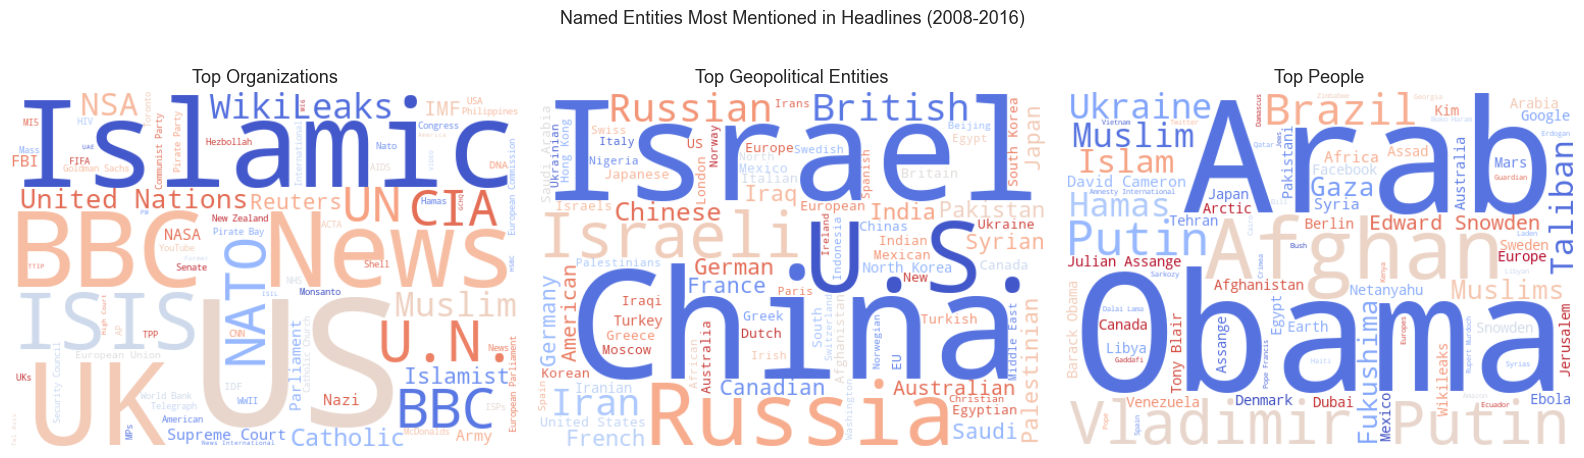

Top 10 Organizations: ['US', 'Islamic', 'UK', 'BBC News', 'ISIS', 'U.N.', 'NATO', 'BBC', 'CIA', 'UN']
Top 10 GPEs: ['China', 'Israel', 'U.S.', 'Russia', 'Israeli', 'Russian', 'Iran', 'British', 'Chinese', 'India']
Top 10 People: ['Obama', 'Arab', 'Afghan', 'Vladimir Putin', 'Putin', 'Brazil', 'Ukraine', 'Muslim', 'Hamas', 'Islam']


In [17]:
# frequency distribution and word clouds for each entity type
org_freq = Counter([e for sublist in final_df['ORG'] for e in sublist])
gpe_freq = Counter([e for sublist in final_df['GPE'] for e in sublist])
per_freq = Counter([e for sublist in final_df['PER'] for e in sublist])

# word clouds
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
settings = dict(background_color='white', width=500, height=350,
                max_words=80, colormap='coolwarm', random_state=42)

for ax, freq, title in zip(
    axes,
    [org_freq, gpe_freq, per_freq],
    ['Top Organizations', 'Top Geopolitical Entities', 'Top People']
):
    if freq:
        wc = WordCloud(**settings).generate_from_frequencies(freq)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(title, fontsize=13)

plt.tight_layout()
plt.suptitle('Named Entities Most Mentioned in Headlines (2008-2016)', fontsize=13, y=1.02)
plt.show()

print('Top 10 Organizations:', [e for e, _ in org_freq.most_common(10)])
print('Top 10 GPEs:',          [e for e, _ in gpe_freq.most_common(10)])
print('Top 10 People:',        [e for e, _ in per_freq.most_common(10)])

# save top 100 of each for Naive Bayes features
top_orgs = [e for e, _ in FreqDist(org_freq).most_common(100)]
top_gpes = [e for e, _ in FreqDist(gpe_freq).most_common(100)]
top_pers = [e for e, _ in FreqDist(per_freq).most_common(100)]

---
## 7. Train / Test Split

I use a time-based split — NOT random splitting.

**Why time-based?** Random splitting would cause data leakage — future information leaking into training. If I train on a mix of 2008 and 2016 data, the model sees patterns from the future that it wouldn't have access to in real deployment. Time-based split mimics how a real trading system would work.

- **Train:** 2008-08-08 to 2014-12-31 (~80%)
- **Test:**  2015-01-02 to 2016-07-01 (~20%)

In [18]:
sentiment_features = ['Positive_Score', 'Negative_Score', 'Neutral_Score', 'Compound_Score']
lagged_features    = [f'Lag_{c}' for c in sentiment_features]
tfidf_features     = list(tfidf_vectorizer.get_feature_names_out())
all_features       = sentiment_features + lagged_features + tfidf_features

train_df = final_df[(final_df['Date'] >= '2008-08-08') & (final_df['Date'] <= '2014-12-31')]
test_df  = final_df[(final_df['Date'] >= '2015-01-02') & (final_df['Date'] <= '2016-07-01')]

X_train = train_df[all_features].fillna(0)
X_test  = test_df[all_features].fillna(0)
y_train = train_df['Label']
y_test  = test_df['Label']

# align indices
y_train = y_train.loc[X_train.index]
y_test  = y_test.loc[X_test.index]

print(f'Training set:  {X_train.shape[0]:,} days ({y_train.mean():.1%} label=1)')
print(f'Test set:      {X_test.shape[0]:,} days ({y_test.mean():.1%} label=1)')
print(f'Total features: {X_train.shape[1]:,}')

# apply SMOTE to training set to handle class imbalance
# SMOTE creates synthetic minority class samples — balances 0/1 without throwing away data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE:')
print(f'  Label 0: {(y_train_bal == 0).sum():,}')
print(f'  Label 1: {(y_train_bal == 1).sum():,}')

Training set:  1,611 days (54.2% label=1)
Test set:      378 days (50.8% label=1)
Total features: 1,008

After SMOTE:
  Label 0: 873
  Label 1: 873


---
## 8. Model Training

I train three models and compare them systematically:

| Model | Why I use it |
|-------|-------------|
| Random Forest | Handles high-dimensional sparse data, captures non-linear patterns, robust to noise |
| Logistic Regression | Strong baseline for text classification, interpretable coefficients, handles TF-IDF sparsity well |
| Naive Bayes | Specifically designed for text features, fast, good with NER binary features |

All models use the same train/test split for fair comparison. I tune Random Forest with GridSearchCV and Logistic Regression with L1/L2 regularization.

In [19]:
# helper function to evaluate any model consistently
def evaluate_model(name, y_true, y_pred, y_prob=None):
    """Print classification report and return key metrics as a dict."""
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else None

    print(f'=== {name} ===')
    print(f'Accuracy:  {acc:.3f}')
    if auc: print(f'ROC-AUC:   {auc:.3f}')
    print(classification_report(y_true, y_pred, target_names=['Down (0)', 'Up (1)']))

    return {'Model': name, 'Accuracy': acc, 'ROC-AUC': auc}


results = []  # I'll collect all model results here for final comparison

In [20]:
# --- Model 1: Random Forest with GridSearchCV ---
# I tune key hyperparameters:
# n_estimators: more trees = better stability (but slower)
# max_depth: controls overfitting — None = fully grown trees
# min_samples_split: minimum samples to split a node

print('Tuning Random Forest with GridSearchCV (this takes a few minutes)...')

param_grid_rf = {
    'n_estimators':    [100, 200],
    'max_depth':       [10, 20, None],
    'min_samples_split': [2, 5],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_rf,
    scoring='roc_auc',
    cv=3,
    verbose=0,
    n_jobs=-1
)
grid_rf.fit(X_train_bal, y_train_bal)

print(f'Best RF params: {grid_rf.best_params_}')

rf_model    = grid_rf.best_estimator_
y_pred_rf   = rf_model.predict(X_test)
y_prob_rf   = rf_model.predict_proba(X_test)[:, 1]

rf_results = evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)
results.append(rf_results)

Tuning Random Forest with GridSearchCV (this takes a few minutes)...
Best RF params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
=== Random Forest ===
Accuracy:  0.489
ROC-AUC:   0.471
              precision    recall  f1-score   support

    Down (0)       0.45      0.18      0.25       186
      Up (1)       0.50      0.79      0.61       192

    accuracy                           0.49       378
   macro avg       0.48      0.48      0.43       378
weighted avg       0.48      0.49      0.44       378



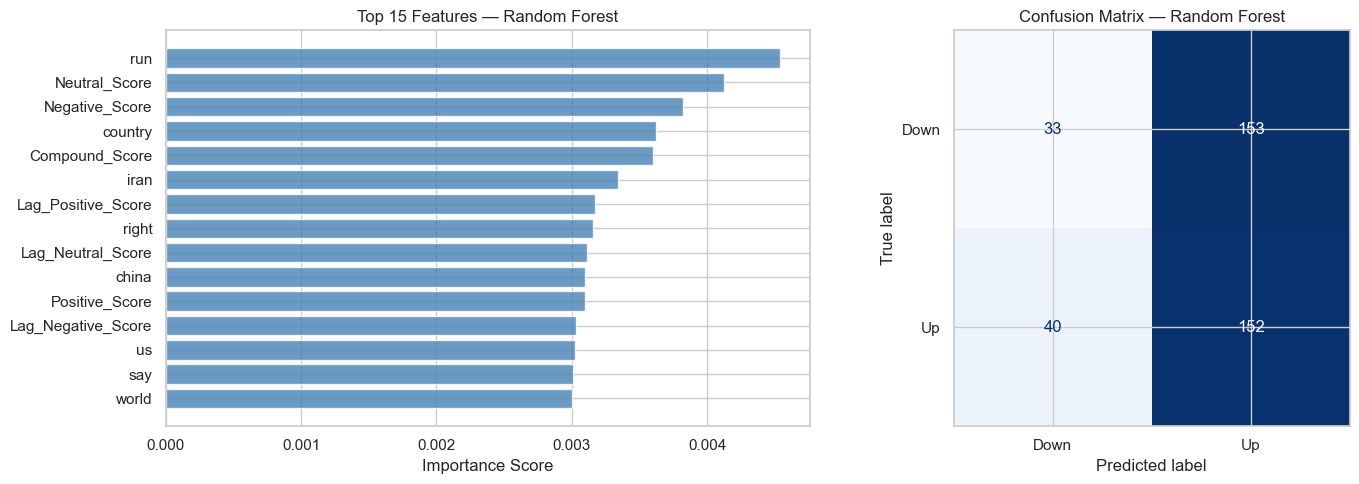

In [21]:
# feature importance — which words/features drove RF predictions?
feat_imp = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# top 15 features
top15 = feat_imp.head(15)
axes[0].barh(top15['Feature'][::-1], top15['Importance'][::-1],
             color='steelblue', alpha=0.8)
axes[0].set_title('Top 15 Features — Random Forest')
axes[0].set_xlabel('Importance Score')

# confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — Random Forest')

plt.tight_layout()
plt.show()

In [22]:
# --- Model 2: Logistic Regression with L1/L2 regularization ---
# Logistic Regression works well with sparse TF-IDF features
# L1 regularization performs feature selection (drives irrelevant coefficients to exactly 0)
# L2 regularization shrinks all coefficients (keeps all features, reduces overfitting)
# C = inverse of regularization strength (lower C = stronger regularization)

param_grid_lr = {
    'C':       [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear']  # required for L1
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid_lr,
    scoring='roc_auc',
    cv=3,
    verbose=0
)
grid_lr.fit(X_train_bal, y_train_bal)

print(f'Best LR params: {grid_lr.best_params_}')

lr_model   = grid_lr.best_estimator_
y_pred_lr  = lr_model.predict(X_test)
y_prob_lr  = lr_model.predict_proba(X_test)[:, 1]

lr_results = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)
results.append(lr_results)

Best LR params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
=== Logistic Regression ===
Accuracy:  0.463
ROC-AUC:   0.447
              precision    recall  f1-score   support

    Down (0)       0.45      0.43      0.44       186
      Up (1)       0.47      0.49      0.48       192

    accuracy                           0.46       378
   macro avg       0.46      0.46      0.46       378
weighted avg       0.46      0.46      0.46       378



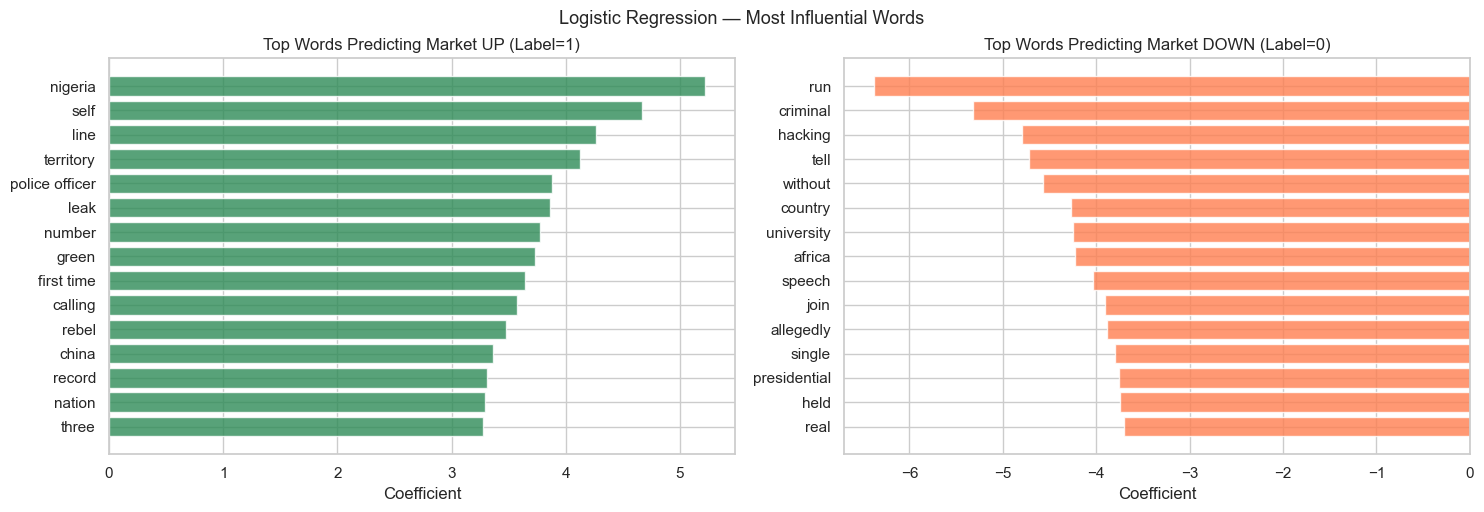

In [23]:
# logistic regression coefficients — most predictive words
# positive coefficient = word associated with market going UP
# negative coefficient = word associated with market going DOWN

coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# top positive (predicts UP)
top_pos = coef_df.head(15)
axes[0].barh(top_pos['Feature'][::-1], top_pos['Coefficient'][::-1],
             color='seagreen', alpha=0.8)
axes[0].set_title('Top Words Predicting Market UP (Label=1)')
axes[0].set_xlabel('Coefficient')

# top negative (predicts DOWN)
top_neg = coef_df.tail(15)
axes[1].barh(top_neg['Feature'], top_neg['Coefficient'],
             color='coral', alpha=0.8)
axes[1].set_title('Top Words Predicting Market DOWN (Label=0)')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.suptitle('Logistic Regression — Most Influential Words', fontsize=13, y=1.02)
plt.show()

In [24]:
# --- Model 3: Naive Bayes with NER features ---
# Naive Bayes assumes all features are conditionally independent (naive assumption)
# but it works surprisingly well for text classification
# I use binary NER features: does today's headlines mention Apple? The Fed? Obama?
# The intuition: certain entities systematically correlate with market movements

def build_ner_features(news_text, orgs, gpes, pers):
    """Build binary feature dict: does this text mention each top entity?"""
    features = {}
    for org in top_orgs: features[f'ORG_{org}'] = (org in orgs)
    for gpe in top_gpes: features[f'GPE_{gpe}'] = (gpe in gpes)
    for per in top_pers: features[f'PER_{per}'] = (per in pers)
    return features

# build feature sets for NLTK Naive Bayes
featuresets = [
    (build_ner_features(text, org, gpe, per), label)
    for text, org, gpe, per, label in zip(
        final_df['Cleaned_Text'], final_df['ORG'],
        final_df['GPE'], final_df['PER'], final_df['Label']
    )
]

# time-based split (match the same dates as RF/LR)
train_mask = (final_df['Date'] >= '2008-08-08') & (final_df['Date'] <= '2014-12-31')
test_mask  = (final_df['Date'] >= '2015-01-02') & (final_df['Date'] <= '2016-07-01')

nb_train = [featuresets[i] for i in final_df[train_mask].index]
nb_test  = [featuresets[i] for i in final_df[test_mask].index]

nb_classifier = nltk.NaiveBayesClassifier.train(nb_train)

y_test_nb = [label for _, label in nb_test]
y_pred_nb = [nb_classifier.classify(features) for features, _ in nb_test]

nb_results = evaluate_model('Naive Bayes (NER features)', y_test_nb, y_pred_nb)
results.append(nb_results)

print()
print('=== Most Informative NER Features ===')
nb_classifier.show_most_informative_features(10)

=== Naive Bayes (NER features) ===
Accuracy:  0.481
              precision    recall  f1-score   support

    Down (0)       0.46      0.34      0.39       186
      Up (1)       0.49      0.62      0.55       192

    accuracy                           0.48       378
   macro avg       0.48      0.48      0.47       378
weighted avg       0.48      0.48      0.47       378


=== Most Informative NER Features ===
Most Informative Features
              ORG_Africa = True                1 : 0      =      5.9 : 1.0
                 ORG_EUs = True                1 : 0      =      4.8 : 1.0
                  ORG_BP = True                0 : 1      =      4.5 : 1.0
    ORG_Foreign Ministry = True                1 : 0      =      3.9 : 1.0
          PER_Boko Haram = True                1 : 0      =      2.7 : 1.0
                ORG_MH17 = True                0 : 1      =      2.6 : 1.0
            PER_Zimbabwe = True                0 : 1      =      2.4 : 1.0
             GPE_Nigeria = True

---
## 9. Model Comparison

Now I compare all three models side by side on the same test set. I use three metrics:

- **Accuracy**: overall % correct — can be misleading with imbalanced classes
- **ROC-AUC**: measures ranking quality, independent of threshold. AUC=0.5 = random, AUC=1.0 = perfect
- **F1-score**: harmonic mean of precision and recall — better for imbalanced problems

For a market prediction problem, I care most about ROC-AUC because it tells me whether the model's confidence rankings are meaningful — not just whether it gets the threshold right.

=== Model Comparison ===
                     Model  Accuracy  ROC-AUC
             Random Forest  0.489418 0.470598
       Logistic Regression  0.462963 0.446937
Naive Bayes (NER features)  0.481481      NaN


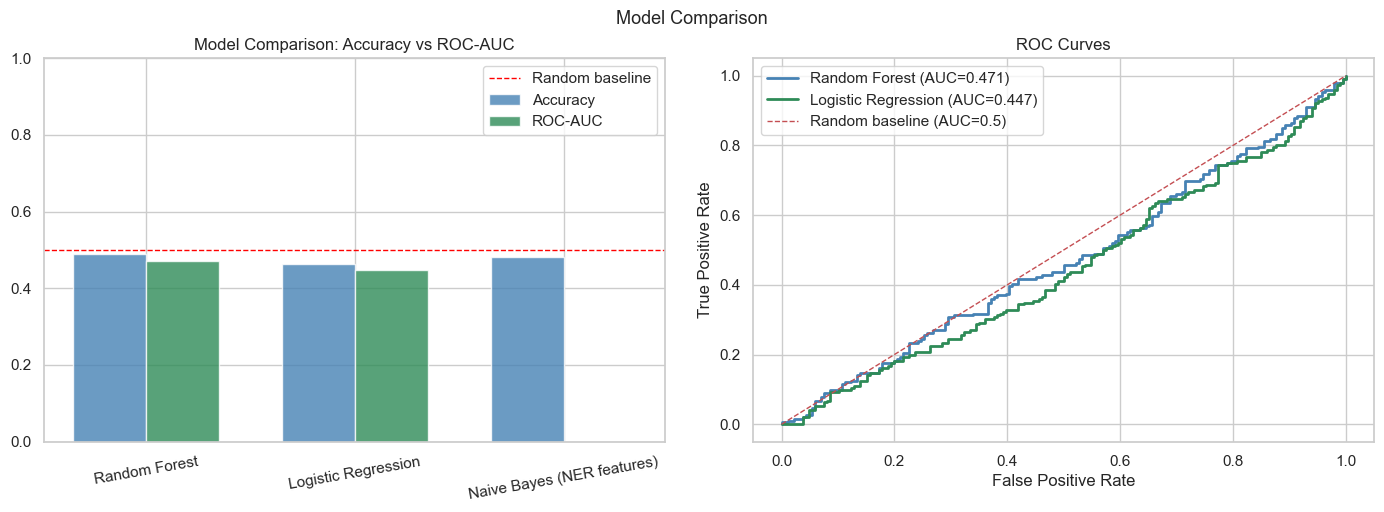

In [25]:
# consolidated results table
results_df = pd.DataFrame(results)
print('=== Model Comparison ===')
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# accuracy and AUC bar chart
x     = range(len(results_df))
width = 0.35
axes[0].bar([i - width/2 for i in x], results_df['Accuracy'],
            width, label='Accuracy', color='steelblue', alpha=0.8)
axes[0].bar([i + width/2 for i in x],
            results_df['ROC-AUC'].fillna(0),
            width, label='ROC-AUC', color='seagreen', alpha=0.8)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random baseline')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=10)
axes[0].set_ylim(0, 1)
axes[0].set_title('Model Comparison: Accuracy vs ROC-AUC')
axes[0].legend()

# ROC curves for models with probability output
for y_prob, name, color in [
    (y_prob_rf, 'Random Forest', 'steelblue'),
    (y_prob_lr, 'Logistic Regression', 'seagreen')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random baseline (AUC=0.5)')
axes[1].set_title('ROC Curves')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.suptitle('Model Comparison', fontsize=13, y=1.02)
plt.show()

---
## 10. Error Analysis — Why Is This Problem So Hard?

Even the best model here performs close to random chance. This is not a failure of the methodology — it reflects a fundamental challenge in financial NLP.

I want to dig into WHERE the models fail and why.

Total test days:              378
Correctly predicted:          185 (48.9%)
High-confidence wrong calls:  0



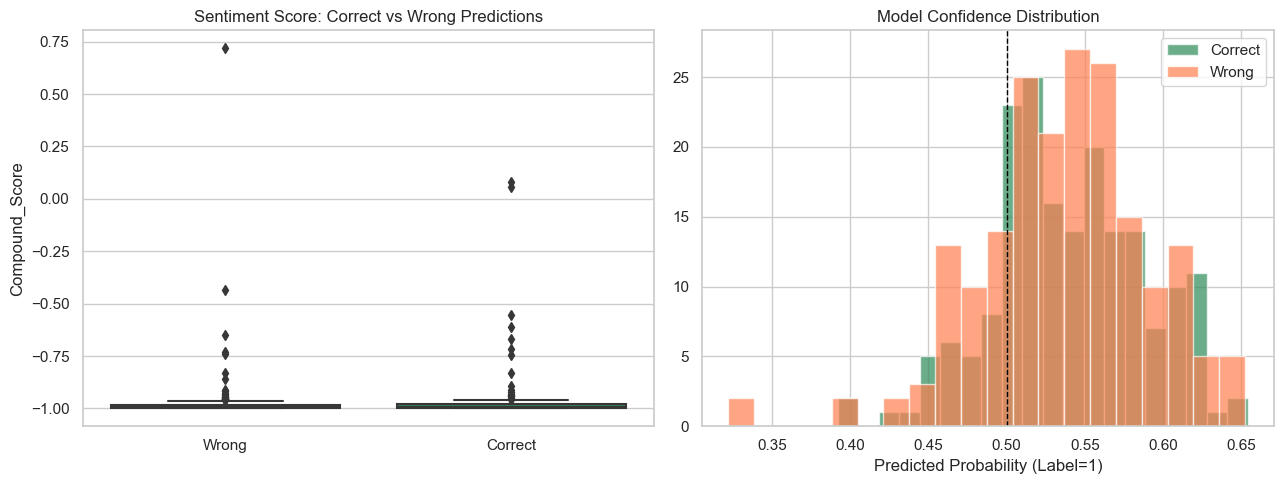

Key observations:
1. Sentiment scores are similar for correct and wrong predictions
   -> Sentiment is a weak signal for market direction
2. Confidence is clustered near 0.5 for most predictions
   -> The model is genuinely uncertain, not confidently wrong


In [26]:
# analyze where Random Forest (best model) gets it wrong
test_analysis = test_df[['Date', 'Label', 'Cleaned_Text', 'Compound_Score']].copy()
test_analysis = test_analysis.loc[X_test.index].reset_index(drop=True)
test_analysis['RF_Prediction'] = y_pred_rf
test_analysis['RF_Probability'] = y_prob_rf
test_analysis['Correct'] = (test_analysis['Label'] == test_analysis['RF_Prediction'])

# where was the model most confident but wrong?
high_conf_wrong = test_analysis[
    (~test_analysis['Correct']) &
    ((test_analysis['RF_Probability'] > 0.7) | (test_analysis['RF_Probability'] < 0.3))
].sort_values('RF_Probability', ascending=False)

print(f'Total test days:              {len(test_analysis)}')
print(f'Correctly predicted:          {test_analysis["Correct"].sum()} ({test_analysis["Correct"].mean():.1%})')
print(f'High-confidence wrong calls:  {len(high_conf_wrong)}')
print()

# sentiment on correct vs incorrect predictions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x='Correct', y='Compound_Score', data=test_analysis, ax=axes[0],
            palette={True: 'seagreen', False: 'coral'})
axes[0].set_title('Sentiment Score: Correct vs Wrong Predictions')
axes[0].set_xticklabels(['Wrong', 'Correct'])
axes[0].set_xlabel('')

# prediction confidence distribution
axes[1].hist(test_analysis[test_analysis['Correct']]['RF_Probability'],
             bins=20, alpha=0.7, color='seagreen', label='Correct')
axes[1].hist(test_analysis[~test_analysis['Correct']]['RF_Probability'],
             bins=20, alpha=0.7, color='coral', label='Wrong')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Model Confidence Distribution')
axes[1].set_xlabel('Predicted Probability (Label=1)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Key observations:')
print('1. Sentiment scores are similar for correct and wrong predictions')
print('   -> Sentiment is a weak signal for market direction')
print('2. Confidence is clustered near 0.5 for most predictions')
print('   -> The model is genuinely uncertain, not confidently wrong')

---
## 11. Final Summary and Conclusions

I want to be honest about what this project showed — not just report the best-looking numbers.

In [27]:
print('=' * 65)
print('NLP STOCK PREDICTION — FINAL REPORT')
print('=' * 65)
print()
print('--- Dataset ---')
print(f'Training period: 2008-08-08 to 2014-12-31')
print(f'Test period:     2015-01-02 to 2016-07-01')
print(f'Features:        TF-IDF (1000) + VADER sentiment (4) + lagged (4) = 1,008')
print(f'NER features:    Top 100 ORG + GPE + PER (for Naive Bayes)')
print()
print('--- Model Results ---')
print(results_df.to_string(index=False))
print()
print('--- Why Performance Is Near Random Chance ---')
print()
print('1. Efficient Market Hypothesis (EMH)')
print('   Markets already price in publicly available news.')
print('   By the time Reddit headlines are posted, the market has reacted.')
print()
print('2. Signal-to-noise ratio')
print('   25 headlines per day contain many irrelevant topics.')
print('   Bag-of-words/TF-IDF loses the context that makes a headline meaningful.')
print()
print('3. VADER limitations')
print('   VADER was trained on social media sentiment, not financial language.')
print('   "The Fed raised rates" is neutral to VADER but bullish or bearish depending on context.')
print()
print('4. Missing features')
print('   Market movement is driven by volume, options flow, macroeconomic data,')
print('   earnings surprises — none of which are in this text dataset.')
print()
print('--- What Would Improve Performance ---')
print()
print('1. FinBERT instead of VADER — a BERT model fine-tuned on financial text')
print('   captures nuanced financial language far better than dictionary-based VADER.')
print()
print('2. Intraday timing — use pre-market news only, not same-day headlines')
print('   to avoid leaking post-market information into the prediction.')
print()
print('3. Additional numeric features — VIX (fear index), trading volume,')
print('   sector performance, and macro indicators alongside text features.')
print()
print('4. Longer lag windows — test 2, 3, 5-day lags instead of just 1-day')
print('   since market reactions to news can be delayed.')
print('=' * 65)

NLP STOCK PREDICTION — FINAL REPORT

--- Dataset ---
Training period: 2008-08-08 to 2014-12-31
Test period:     2015-01-02 to 2016-07-01
Features:        TF-IDF (1000) + VADER sentiment (4) + lagged (4) = 1,008
NER features:    Top 100 ORG + GPE + PER (for Naive Bayes)

--- Model Results ---
                     Model  Accuracy  ROC-AUC
             Random Forest  0.489418 0.470598
       Logistic Regression  0.462963 0.446937
Naive Bayes (NER features)  0.481481      NaN

--- Why Performance Is Near Random Chance ---

1. Efficient Market Hypothesis (EMH)
   Markets already price in publicly available news.
   By the time Reddit headlines are posted, the market has reacted.

2. Signal-to-noise ratio
   25 headlines per day contain many irrelevant topics.
   Bag-of-words/TF-IDF loses the context that makes a headline meaningful.

3. VADER limitations
   VADER was trained on social media sentiment, not financial language.
   "The Fed raised rates" is neutral to VADER but bullish or beari